# Prediciendo diabetes


#### Paso 1: Carga del conjunto de datos

In [1]:
import pandas as pd

url = "https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv"
df = pd.read_csv(url)

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


#### Paso 2: EDA completo y división del dataset

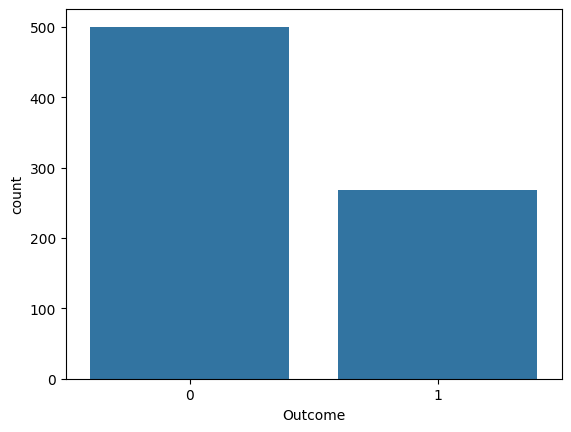

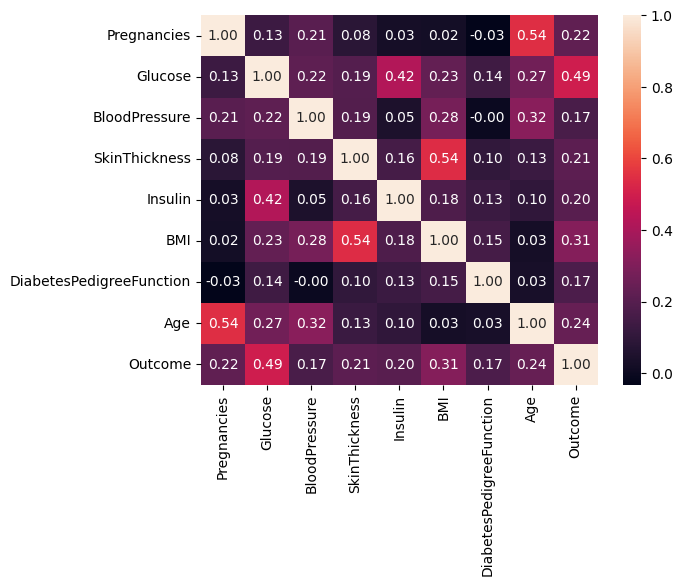

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df.isnull().sum()
df.duplicated().sum()

cols_with_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in cols_with_zero:
    df[col] = df[col].replace(0, np.nan)

df.fillna(df.median(), inplace=True)

plt.figure()
sns.countplot(x="Outcome", data=df)
plt.show()

plt.figure()
sns.heatmap(df.corr(), annot=True, fmt=".2f")
plt.show()

from sklearn.model_selection import train_test_split

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#### Paso 3: Modelo de árbol de decisión

Criterio: gini
Accuracy: 0.6818181818181818
[[79 21]
 [28 26]]
              precision    recall  f1-score   support

           0       0.74      0.79      0.76       100
           1       0.55      0.48      0.51        54

    accuracy                           0.68       154
   macro avg       0.65      0.64      0.64       154
weighted avg       0.67      0.68      0.68       154



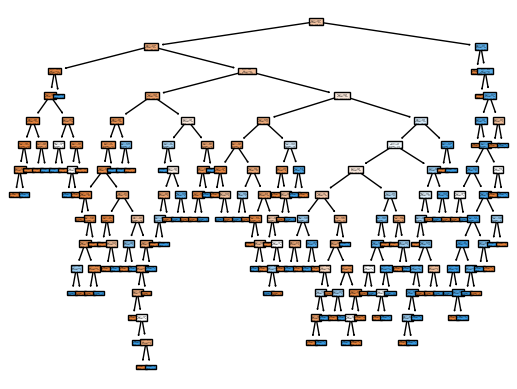

Criterio: entropy
Accuracy: 0.6753246753246753
[[76 24]
 [26 28]]
              precision    recall  f1-score   support

           0       0.75      0.76      0.75       100
           1       0.54      0.52      0.53        54

    accuracy                           0.68       154
   macro avg       0.64      0.64      0.64       154
weighted avg       0.67      0.68      0.67       154



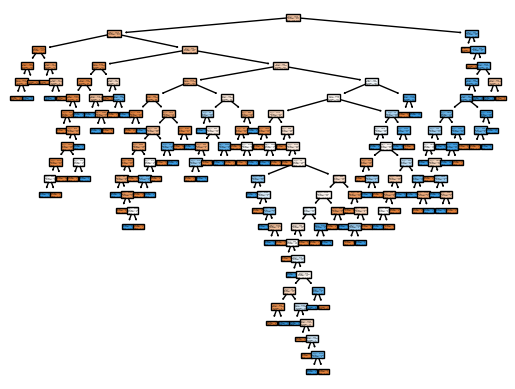

Criterio: log_loss
Accuracy: 0.6753246753246753
[[76 24]
 [26 28]]
              precision    recall  f1-score   support

           0       0.75      0.76      0.75       100
           1       0.54      0.52      0.53        54

    accuracy                           0.68       154
   macro avg       0.64      0.64      0.64       154
weighted avg       0.67      0.68      0.67       154



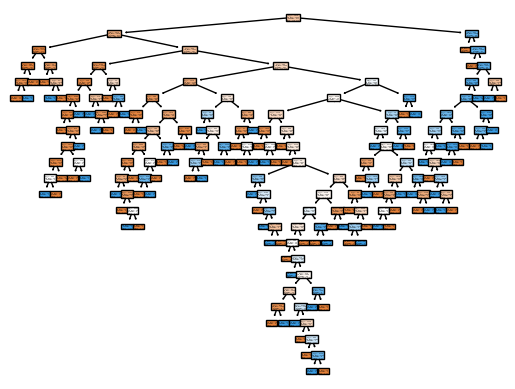

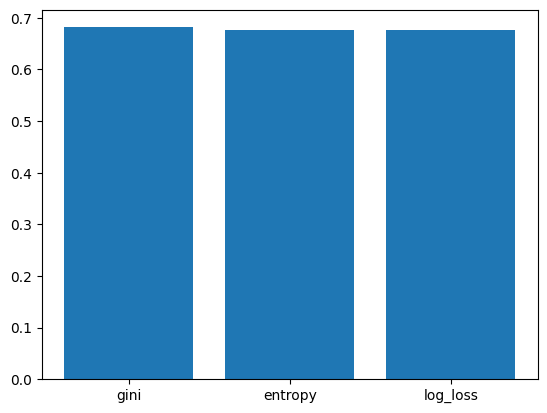

In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import plot_tree

criterios = ["gini", "entropy", "log_loss"]

resultados = {}

for criterio in criterios:
    model = DecisionTreeClassifier(criterion=criterio, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    resultados[criterio] = acc

    print("Criterio:", criterio)
    print("Accuracy:", acc)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    plt.figure()
    plot_tree(model, filled=True)
    plt.show()

plt.figure()
plt.bar(resultados.keys(), resultados.values())
plt.show()

#### Paso 4: Optimización con Grid Search

Mejores parámetros: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy final: 0.6883116883116883
[[92  8]
 [40 14]]
              precision    recall  f1-score   support

           0       0.70      0.92      0.79       100
           1       0.64      0.26      0.37        54

    accuracy                           0.69       154
   macro avg       0.67      0.59      0.58       154
weighted avg       0.68      0.69      0.64       154



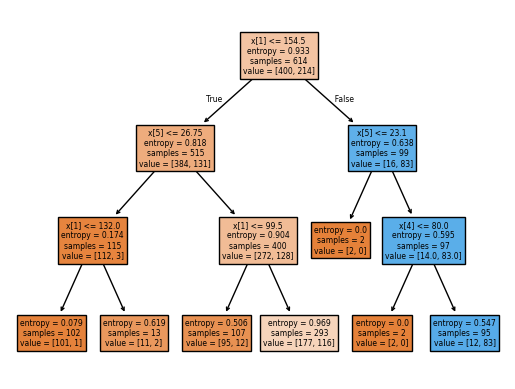

In [4]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [None, 3, 5, 7, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy", "log_loss"]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

print("Mejores parámetros:", grid.best_params_)
print("Accuracy final:", accuracy_score(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

plt.figure()
plot_tree(best_model, filled=True)
plt.show()

### Conclusion

##### El modelo de árbol de decisión permite clasificar pacientes con diabetes utilizando variables clínicas relevantes. Tras comparar los distintos criterios de pureza, se observa que las diferencias en desempeño suelen ser pequeñas, aunque uno puede presentar mejor generalización. La optimización mediante Grid Search mejora el rendimiento al controlar la profundidad y el tamaño mínimo de los nodos, reduciendo el sobreajuste y obteniendo un modelo más robusto para predicción.